In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.style.use('ggplot')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

In [2]:
from scipy.special import spence

In [3]:
import mpmath as mp
mp.dps    = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

# Basic constants
n_0 = mp.mpf('0.0');    n_1 = mp.mpf('1.0');    n_2 = mp.mpf('2.0');    n_3 = mp.mpf('3.0');    n_4 = mp.mpf('4.0')

Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


Let $E_\varepsilon := K \ast \mathbf{1}_{●}$ and let $x \in \mathbb{R}^2$ with norm $a := \|x\|$.  Then, the value of $E_\varepsilon(x)$ depends on the distance of $x$ to the origin, and it is given as follows:
\begin{align*}
    E_\varepsilon (x) = \frac{1}{2\pi} \int_{ x - ● } \log |y| \, dy
    =
\frac{1}{4}
\begin{cases}
\varepsilon^2 (\log \varepsilon^2 - 1) 
    & \text{if } a \in [0,1-\varepsilon],
\\
\dfrac{1}{\pi} (\pi - \varphi) \varepsilon^2 ( \log \varepsilon^2 - 1) 
    + 8 F_\varepsilon (a,\varphi)
    & \text{if } a \in (1-\varepsilon, 1+\varepsilon),
\\
0 & \text{if } a \in [1+\varepsilon, \infty),
\end{cases}
\end{align*}
where the intersection angle $\varphi = \varphi_\varepsilon (a) \in [0, \pi]$ is defined by
\begin{align*}
\varphi := \arccos \frac{1 - a^2 - \varepsilon^2}{2 a \varepsilon}
\qquad
\forall a \in [1-\varepsilon,1+\varepsilon].
\end{align*}

The function $F_\varepsilon: D \to \mathbb{R}$, defined on the set
\begin{align*}
D = \{ (a, \varphi) : a \in [1-\varepsilon, 1+\varepsilon],\ \varphi = \varphi_\varepsilon (a) \},
\end{align*}
is continuous and given by the following piecewise formula. For $a \geq 1$ we introduce $\alpha := \arcsin \frac{1}{a}$; then
\begin{equation}
\label{eq:Fun_M}
    F_\varepsilon (a, \varphi)
    =
\frac{1}{8\pi}
\begin{cases}
G\bigl(a; \Phi(\varphi)\bigr) - \pi (1-a^2) 
    & \text{for } 1-\varepsilon \leq a < 1,
\\
G\bigl(1; \Phi(\varphi)\bigr)
    & \text{for } a = 1,
\\
G\bigl(a; \Phi(\varphi)\bigr) - 2\pi \log a - 2G\bigl(a; \tfrac{1}{4}(\pi + 2\alpha) \bigr)
    & \text{for } 1 < a < \sqrt{1 + \varepsilon^2},
\\
- 2\pi \log a - G\bigl(a; \Phi(\varphi + \pi)\bigr)
    & \text{for } \sqrt{1 + \varepsilon^2} \leq a \leq 1+\varepsilon.
\end{cases}
\end{equation}

Here, $\Phi: [0,2\pi] \to [0, \tfrac{\pi}{2}]$ is the composition
\begin{align*}
s(\theta) := -a \cos \theta + \sqrt{ 1 - a^2 \sin^2 \theta },
\qquad
L(\theta) := \frac{s^2 (\theta) - 1 - a^2}{2a},
\qquad
\Phi(\theta) := \frac{1}{2} \arccos L(\theta);
\end{align*}
and $G: [1-\varepsilon, 1+\varepsilon] \times [0,2\pi] \to \mathbb{R}$ is the continuous function
\begin{align*}
\begin{aligned}
G(a;\phi)
&:=
2 \Im \bigl( \operatorname{Li}(-a e^{2i\phi}) \bigr)
+ (1-a^2) \left[ 2 \phi - \arctan\left(\frac{ a \sin 2\phi}{1 + a \cos 2\phi} \right)  \right]
+ a\bigl( 2- \log(1+ a^2 +2a\cos 2\phi)  \bigr)\sin 2\phi,
\end{aligned}
\end{align*}
where $\operatorname{Li} : \mathbb{C} \to \mathbb{C}$ denotes the dilogarithm on a continuous branch.

---

In this notebook, we are interested in computing the function $E_\varepsilon$ efficiently. 

---

For points inside the interval $[1-\varepsilon,\,1+\varepsilon]$, these will be parametrised by
\begin{equation}
	\lambda
	:=
	\frac{a - 1}{2\varepsilon} + \frac{1}{2},
	\qquad
	a = a(\lambda,\varepsilon)
	:=
	1 - (1-2\lambda)\varepsilon,
	\qquad
	\lambda \in [0,1].
\end{equation}

We will employ three assymptotic expansions:

1. We approximate $F_\varepsilon$
\begin{align*}
    F_\varepsilon (\lambda) \sim H(\lambda,\varepsilon) =
		\begin{cases} 
			h_1^{(1)} (\lambda) \varepsilon^2 \log \varepsilon^2 + h_2^{(1)} (\lambda) \varepsilon^2 + O(\varepsilon^3) & \text{if } \lambda \in (0,1/2),
            \\
            h_1^{(1)} (1-\lambda) \varepsilon^2 \log \varepsilon^2 + h_2^{(1)} (1-\lambda) \varepsilon^2 + O(\varepsilon^3) & \text{otherwise},
        \end{cases}
\end{align*}
where $ \omega_\pm = \arccos( \pm(1-2\lambda) )$ and
\begin{align*}
		h_1^{(1)} (\lambda) &= \frac{1}{4\pi} (1-2\lambda) \sqrt{ \lambda (1-\lambda) },
		\qquad
		h_2^{(1)}(\lambda) = \frac{1-2\lambda}{4\pi} \left[ (1-2\lambda) \omega_+ - 3\sqrt{\lambda (1-\lambda)} \right].
\end{align*}

2. We approximate $\varphi$ by
\begin{equation}
		\varphi = \varphi_\varepsilon (a(\lambda,\varepsilon) ) = 
		\arccos(1-2\lambda) + \sqrt{ \lambda(1-\lambda)} \varepsilon + \frac{3}{4} (1-2\lambda) \sqrt{ \lambda (1-\lambda) } \varepsilon^2 + O(\varepsilon^3).
\end{equation}

3. The exact expansion at $a=1$:
	\begin{equation}
		F_\varepsilon(1,\varepsilon) =
		\frac{1}{8\pi} G(1; \Phi(\varphi))
		=
		\frac{1}{144\pi} \left( 2 \varepsilon^3 \log \varepsilon^3 - 5 \varepsilon^3 \right)
		+ O(\varepsilon^5 \log \varepsilon) .
	\end{equation}

We focus on a one-dimensional evaluation, although it is very straightforward to evaluate the two-dimensional function.

In [4]:
def s(a, θ):
    # Stable computation of s(θ)
    sinθ, cosθ = mp.sin(θ), mp.cos(θ)
    if θ == n_0:
        sinθ, cosθ = n_0, n_1
    elif n_2 * θ == mp.pi:
        sinθ, cosθ = n_1, n_0
    elif n_2 * θ == mp.mpf('3.0') * mp.pi:
        sinθ, cosθ = -n_1, n_0
    elif θ == mp.pi:
        sinθ, cosθ = n_0, -n_1
    elif θ == n_2 * mp.pi:
        sinθ, cosθ = n_0, n_1
    elif (mp.sin(θ) * a == n_1) and (a > n_1):
        if cosθ < n_0:
            sinθ, cosθ = n_1/a, -mp.sqrt(a*a-n_1)/a            # π - α
        else:
            sinθ, cosθ = n_1/a,  mp.sqrt(a*a-n_1)/a            # α
    elif (mp.sin(θ) * a == -n_1) and (a > n_1):
        sinθ, cosθ = -n_1/a, mp.sqrt(a*a-n_1)/a                # 2π - α
        
        
        
    R = n_1 - (a*a)*(sinθ * sinθ)
    if (abs(mp.sin(θ)) * a == n_1) and (a>n_1):
        R = n_0
    
    # Trim under precision
    if R < -mp.mpf('10')**-(mp.dps-2):
        return n_0
        
    # Clip and process
    if abs(R) <= mp.mpf('10')**-(mp.dps-2):
        s_out = -a * cosθ
    else:
        s_out = -a * cosθ + mp.sqrt(R)    
    
    if a == n_1:
        if cosθ >= n_0:
            s_out = n_0
        else:
            s_out = -n_2 * cosθ
    return s_out
def f(a,θ):
    s_aθ = s(a, θ)
    if s_aθ == n_0:
        return n_0
    return (s_aθ * s_aθ) * (n_2 * mp.log(abs(s_aθ)) - n_1)
def φ_from(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    cos  = n_1 - a*a - ε*ε
    cos /= n_2 * a * ε
    
    # Special cases
    if a == n_1 - ε:              # cos φ = 1
        return n_0
    elif a == n_1 + ε:            # cos φ = -n_1
        return mp.pi
    elif mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):    #a*a == n_1 + ε*ε:        # cos φ = -ε/mp.sqrt(1 + ε^2)
        #return mp.acos(-ε/mp.sqrt(n_1 + ε*ε))
        return mp.atan(ε) + mp.pi/n_2
    elif mp.almosteq(a*a, n_1 - ε*ε, abs_eps = þ):    #a*a == n_1 - ε*ε:        # cos φ = n_0
        return mp.pi/n_2
    elif a == n_1:                # cos φ = -ε/2
        return mp.acos(-ε/n_2)
        
    return mp.acos(cos)
def Φ(a, θ):
    '''
        Variable transformation
    '''
    sθ = s(a, θ)
    Lθ = (sθ * sθ - n_1 - a*a)/(n_2 * a)        # Range [-1,1]
    if a == n_1:
        Lθ = (sθ * sθ / n_2) - n_1
    ϕ  = mp.acos(Lθ) / n_2                      # Range [0,π/2]
    return ϕ

In [5]:
# Extended-precision G
def G_mp(a,ϕ):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    '''
        Angular quantities
    '''
    cosϕ, cos2ϕ, sin2ϕ = mp.cos(ϕ), mp.cos(n_2 * ϕ), mp.sin(n_2 * ϕ)
    if (n_2 * ϕ == mp.pi):
        cosϕ, cos2ϕ, sin2ϕ = n_0, -n_1, n_0
    if (ϕ == n_0):
        cosϕ, cos2ϕ, sin2ϕ = n_1,  n_1, n_0
    
    '''
        Special cases
    '''
    # G(1;ϕ)
    if (a == n_1):
        if cosϕ == n_0:
            return n_0
        else:
            G  = n_2 * mp.polylog(2, -mp.exp(2j * ϕ)).imag
            G += n_2 * (n_1 - mp.log( n_2 * abs(cosϕ) ) ) * sin2ϕ
            return G
    
    # G(a;π/2)
    '''if mp.almosteq(n_2 * ϕ, mp.pi, abs_eps = þ):
        if a <= 1:
            G = (n_1 - a*a) * mp.pi
        else:
            G = -n_2 * mp.pi * mp.log(a)
        return G'''
    # G(a; 0)
    if ϕ == n_0:
        return n_0
    
    # G(a; (2α+π)/2 )
    if a > n_1:
        α = mp.asin(n_1/a)
        # Exact case
        if mp.almosteq(ϕ * n_4, n_2 * α + mp.pi, abs_eps = þ):
            # Dilog term
            z   = -a * mp.exp(2j * ϕ)
            T_1 = n_2 * mp.polylog(2, z).imag
            # Angular term
            T_2 = (n_1 - a*a) * α
            # Log term
            T_3 = (n_2 - mp.log(a*a - n_1)) * mp.sqrt(a*a - n_1)

            return T_1 + T_2 + T_3
    
    '''
        General case
    '''
    # Dilog term
    z   = -a * mp.exp(2j * ϕ)
    T_1 = n_2 * mp.polylog(2, z).imag
    
    # Angular term
    ang = mp.arg(n_1 - z)
    T_2 = (n_1 - a*a) * (n_2 * ϕ - ang)
    
    # Log term
    l_a = (a - n_1)*(a - n_1)  + n_4 * a * (cosϕ*cosϕ)   # stable version of n_1 + a*a + n_2 * a * cos2ϕ
    T_3 = a * (n_2 - mp.log(l_a) ) * sin2ϕ
    if sin2ϕ == n_0:
        T_3 = n_0
    
    # Collect terms:
    G  = T_1 + T_2 + T_3
    
    return G

In [6]:
# Extended-precision F
def F_mp(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    '''
        Variable transformation
    '''
    θ  = φ_from(a,ε)
    ϕ  = Φ(a,θ)
    
    if (a > n_1):
        # α activates
        α = mp.asin(n_1/a)
        
        # Exact evaluation at breaking point
        if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
            ϕ = (mp.pi - mp.atan(ε))/n_2
            α = mp.pi/n_2 - mp.atan(ε)
        
        # Auxiliary angle = Φ(α)
        ω = (n_2 * α + mp.pi)/n_4
    
    '''
        Functional evaluation
    '''
    if mp.almosteq(a, n_1-ε, abs_eps = þ):
        # At interval extremes, the mass is zero
        T = n_0                               # π ε (2 - ε) cancels out the quadratic term
    elif (a > n_1 - ε) and (a < n_1):
        # One continuous interval of existence
        T = G_mp(a,ϕ) - (n_1 - a*a) * mp.pi
    elif mp.almosteq(a, n_1, abs_eps = þ):
        # One functional evaluation
        T = G_mp(n_1, Φ(n_1, φ_from(n_1,ε) ) )
    elif (a > n_1) and (a*a < n_1 + ε*ε):
        # Two intervals of existence and correct branch selection
        T = G_mp(a,ϕ) - (n_2 * G_mp(a,ω)) - (n_2 * mp.pi * mp.log(a))
    elif (a*a >= n_1 + ε*ε):
        # One interval of continuity, no α involved
        ϕ = Φ(a, θ + mp.pi)
        if mp.almosteq(a*a, n_1 + ε*ε, abs_eps = þ):
            ϕ = (mp.pi - mp.atan(ε))/n_2
        # Principal boundary value (approached from the upper half-plane):  2 im Li_2 (a + 0i) = -2\pi a
        T  = -2*mp.pi*mp.log(a) - G_mp(a,ϕ)
        if mp.almosteq(a, n_1 + ε, abs_eps = þ):
            T = n_0                                     # Φ(φ+π) = π/2 and integral cancels out in the right branch (see previous case)
    
    # Scale
    T /= mp.pi * mp.mpf('8.0')
    
    return T

In [7]:
# Extended-precision E
def E_mp(a,ε):
    þ = mp.mpf('10')**-(mp.dps-2)    # Threshold for equality
    
    '''
        Determine evaluation cases
    '''
    if a <= n_1 - ε:
        E = ε * ε * (mp.log(ε*ε) - n_1)
    elif a >= n_1 + ε:
        E = n_0
    else:
        φ = φ_from(a,ε)
        E = (mp.pi - φ) * ε * ε * (mp.log(ε*ε) - n_1) / mp.pi
        E += mp.mpf('8.0') * F_mp(a,ε)
        
        
    # Scale E
    E /= n_4
    
    return E

In [8]:
N  = 50
nA = np.arange(30,0,-1)[::4]#[-8:]
ε_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
ε_np = np.fromiter((np.float64(x) for x in ε_mp), dtype=np.float64, count=len(ε_mp))

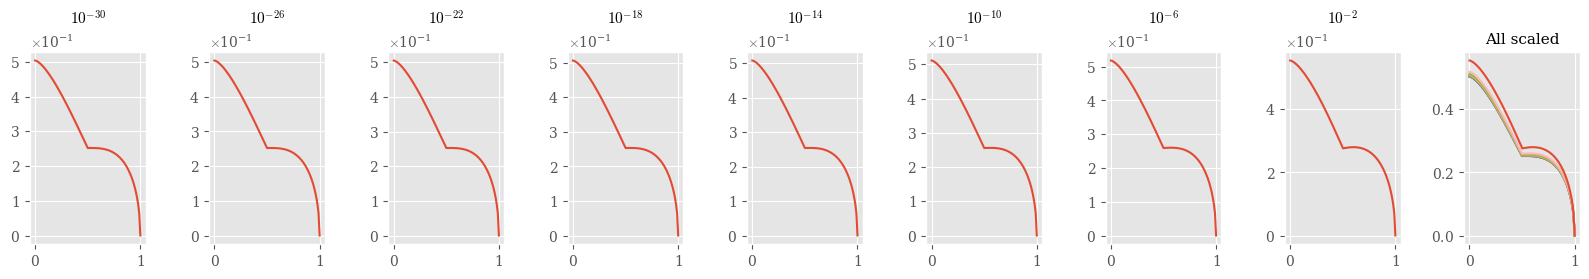

In [9]:
# Plot E(a) inside [1±ε]
fig, ax = plt.subplots(nrows=1, ncols=len(ε_mp)+1, figsize = (20,2.5))
for i in range(len(ε_mp)):
    ε = ε_mp[i]
    λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, n_1/n_2, N) + mp.linspace(n_1/n_2, λₓ, N)[1:-1] + mp.linspace(λₓ, n_1, N)
    A = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    
    f_a = [E_mp( a,ε)/(ε*ε * mp.log(ε)) for a in A]
    ax[i].plot(Λ, f_a)
    ax[i].set_title(leg[i], {'fontsize':11})
    
    ax[-1].plot(Λ, f_a )
    ax[-1].set_title('All scaled', {'fontsize':11})
    
    #ax[0,i % 8].set_yscale('symlog', linthresh = ε * ε * ε*ε)
    ax[i].ticklabel_format(axis='both', style='sci', scilimits=(0,0))

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.55, hspace=0.025)

That is for the $2\varepsilon$ interval. Using a suitable scaling, we can observe the function values on a wider set:

In [10]:
import mpmath as mp
mp.dps    = 2*50 + 30
mp.mp.dps = 2*50 + 30
print(mp.mp)

# Basic constants
n_0 = mp.mpf('0.0');    n_1 = mp.mpf('1.0');    n_2 = mp.mpf('2.0');    n_3 = mp.mpf('3.0');    n_4 = mp.mpf('4.0')

Mpmath settings:
  mp.prec = 435               [default: 53]
  mp.dps = 130                [default: 15]
  mp.trap_complex = False     [default: False]


In [11]:
# Define the transformation: shift, log, and reshift
p = np.float64(-n_1/mp.log(ε));    q = 1.0/p
q = np.float64(-mp.log(ε))
def transform(y):
    return np.sign(y - 1) * np.log1p(np.abs(y - 1.0))**p
def _inv_scalar(y):
    #print(y,q, mp.power(y,q))
    return np.float64(mp.sign(y) * mp.expm1(abs(mp.power(y,q))) + n_1)

def inverse_transform(Y):
    #return np.sign(y) * np.expm1(np.abs(y**q)) + 1.0
    Y = np.asarray(Y)
    inv_vec = np.vectorize(_inv_scalar, otypes=[np.float64])
    return inv_vec(Y)

In [12]:
# Define range of values for ε
nA = np.arange(1,15,1)
ε_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
ε_np = np.fromiter((np.float64(x) for x in ε_mp), dtype=np.float64, count=len(ε_mp))

In [13]:
N  = 50
f_out = np.zeros( (len(ε_mp), (4+2)*N - 3), 'object')
# Evaluate f
for i in range(len(ε_mp)):
    ε = ε_mp[i]
    λₓ_1 = ((ε - n_1) + mp.sqrt(n_1 - ε*ε)) / (n_2 * ε)                            # Not branch, but relevant
    λₓ_2 = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, λₓ_1, N) + mp.linspace(λₓ_1, n_1/n_2, N)[1:] + mp.linspace(n_1/n_2, λₓ_2, N)[1:-1] + mp.linspace(λₓ_2, n_1, N)
    A_pre = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    A = mp.linspace(n_0, n_1 - ε, N) + A_pre + mp.linspace(n_1 + ε, n_2, N)

    f_a = [E_mp(a,ε)/(ε*ε * mp.log(ε)) for a in A]
    f_out[i] = np.asarray(f_a).copy()

In [14]:
# Prepare scaling and decorators for final evaluation
ε = ε_mp[-1]
λₓ = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
p, q = np.float64(-n_1/mp.log(ε)), np.float64(-mp.log(ε))

In [15]:
ax_loc = [0.0, np.float64(n_1 - ε), 1.0, np.float64(mp.sqrt(n_1 + ε*ε)), np.float64(n_1 + ε), 2.0]
ax_lbl = [plt.Text(0, 0, '$\\mathdefault{0}$'), 
          plt.Text(n_1-ε, 0, '$1-\\varepsilon$' ), plt.Text(n_1, 0, '$1$' ), plt.Text(np.float64(mp.sqrt(n_1 + ε*ε)), 0, '$\\sqrt{1+\\varepsilon^2}$' ), 
          plt.Text(n_1+ε, 0, '$1+\\varepsilon$' ), 
          plt.Text(n_2, 0, '$\\mathdefault{2}$')]

In [16]:
from matplotlib.colors import to_hex, to_rgb
def colorFader(c1,c2,mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    c1 = np.array(to_rgb(c1))
    c2 = np.array(to_rgb(c2))
    return to_hex((1-mix)*c1 + mix*c2)

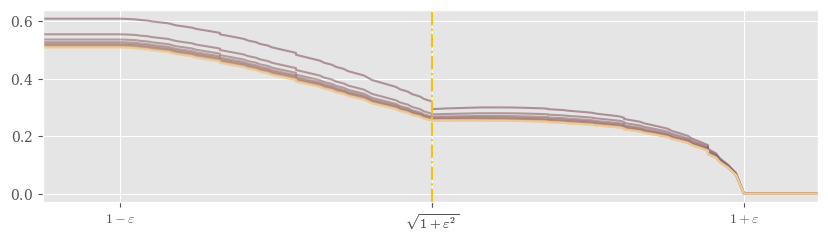

In [17]:
# First plot, might be prone to scaling issues due to matplotlib inner conversion
plt.figure(figsize=(10,2.5))
for i in range(len(ε_mp)):
    plt.plot(A, f_out[i], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )

# Decoration and scaling
#plt.xscale('function', functions=(transform, inverse_transform))

η_1 = 4.1 #np.float64(np.mean(f_out[-1][2*N:-2*N]))
η_2 = 0.6
#plt.yscale('function', functions=(lambda y: np.sign(y - η_1) * np.log1p(np.abs(y - η_1))**η_2, lambda y: np.sign(y) * np.expm1(np.abs(y**(1/η_2) )) + η_1 ))

plt.xticks(ax_loc, ax_lbl);
#plt.yticks([0, 3, 4,   5,6, 10]);
plt.xlim([0,2]);
#plt.ylim([-1,2]);
#plt.axvline(x=1 + np.sqrt(2) * 0.5 * ε, color='xkcd:goldenrod', linestyle = '-.') # Max 1
plt.axvline(x=n_1, color='xkcd:goldenrod', linestyle = '-.') # Max 1

#plt.axhline(y=np.float64(np.mean(f_out[-1][3*N//2:-2*N])) )

#plt.axhline(y=η_1)
#plt.axvline(x=n_1-ε, color='xkcd:goldenrod', linestyle = '-.') # Max 1
#plt.axvline(x=mp.sqrt(n_1-ε*ε), color='xkcd:goldenrod', linestyle = '-.') # Max 1
plt.xlim([float(n_1-1.25*ε), float(n_1+1.25*ε)]);

We can obtain a better plot by splitting each interval accordingly:

In [18]:
# Define range of values for ε
nA = np.arange(1,31,1)
ε_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
ε_np = np.fromiter((np.float64(x) for x in ε_mp), dtype=np.float64, count=len(ε_mp))

In [19]:
N  = 50
f_out = np.zeros( (len(ε_mp), (4+2)*N - 3), 'object')
# Evaluate f
for i in range(len(ε_mp)):
    ε = ε_mp[i]
    λₓ_1 = ((ε - n_1) + mp.sqrt(n_1 - ε*ε)) / (n_2 * ε)                            # Not branch, but relevant
    λₓ_2 = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, λₓ_1, N) + mp.linspace(λₓ_1, n_1/n_2, N)[1:] + mp.linspace(n_1/n_2, λₓ_2, N)[1:-1] + mp.linspace(λₓ_2, n_1, N)
    A_pre = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    A = mp.linspace(n_0, n_1 - ε, N) + A_pre + mp.linspace(n_1 + ε, n_2, N)

    f_a = [E_mp(a,ε)/(ε*ε * mp.log(ε*ε)) for a in A]
    f_out[i] = np.asarray(f_a).copy()

In [20]:
plt.style.use('default')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

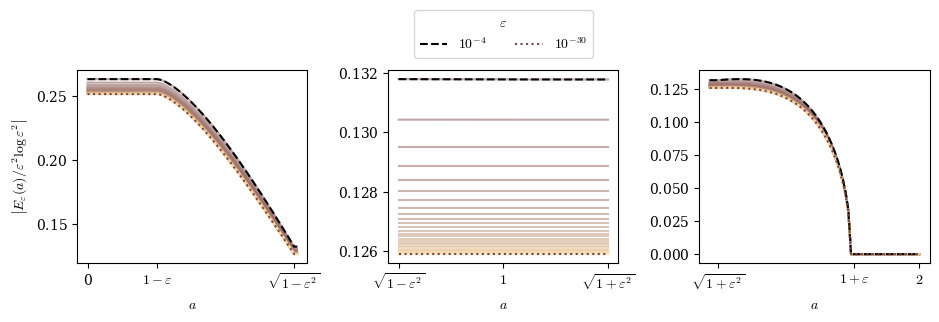

In [21]:
# Plot E(a) inside [0,2]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (11,2.5))

for i in range(3,len(ε_mp)):
    ax[0].plot(f_out[i][N//2:2*N+1], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )    # [0, 1-ε, √(1-ε^2)]
    ax[1].plot(np.arange(len(A))[2*N-1:4*N-2], f_out[i][2*N-1:4*N-2], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )    # [√(1-ε^2), 1, √(1+ε^2)]
    ax[2].plot(np.arange(len(A))[4*N-6:-N//2], f_out[i][4*N-6:-N//2], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )    # [√(1+ε^2),1+ε,2]

    if i == 3:
        ax[0].plot(f_out[i][N//2:2*N+1], color = 'xkcd:black', linestyle = '--', zorder = 3 )
        ax[1].plot(np.arange(len(A))[2*N-1:4*N-2], f_out[i][2*N-1:4*N-2], color = 'xkcd:black', linestyle = '--', label = leg[i], zorder = 3 )
        ax[2].plot(np.arange(len(A))[4*N-6:-N//2], f_out[i][4*N-6:-N//2], color = 'xkcd:black', linestyle = '--', label = leg[i], zorder = 3 )
    
    if i == len(ε_mp)-1:
        ax[0].plot(f_out[i][N//2:2*N+1], color = colorFader('#ffe1a8','#723d46',i/len(ε_mp)), linestyle = ':', zorder = 3 )
        ax[1].plot(np.arange(len(A))[2*N-1:4*N-2], f_out[i][2*N-1:4*N-2], color = colorFader('#ffe1a8','#723d46',i/len(ε_mp)), linestyle = ':', label = leg[i], zorder = 3 )
        ax[2].plot(np.arange(len(A))[4*N-6:-N//2], f_out[i][4*N-6:-N//2], color = colorFader('#ffe1a8','#723d46',i/len(ε_mp)), linestyle = ':', label = leg[i], zorder = 3 )

# First panel
ax_loc = [0, N-N//2, 2*N-1 - N//2] #[0.0, np.float64(n_1 - ε), np.float64(mp.sqrt(n_1 - ε*ε))]
ax_lbl = [plt.Text(0, 0, '$\\mathdefault{0}$'), plt.Text(N-N//2, 0, '$1-\\varepsilon$' ), plt.Text(2*N-1-N//2, 0, '$\\sqrt{1-\\varepsilon^2}$' )]
ax[0].set_xticks(ax_loc, ax_lbl);

# Second panel
ax_loc = [2*N-1, 3*N-2, 4*N-3] #[0.0, np.float64(n_1 - ε), np.float64(mp.sqrt(n_1 - ε*ε))]
ax_lbl = [plt.Text(2*N-1, 0, '$\\sqrt{1-\\varepsilon^2}$'), plt.Text(3*N-1, 0, '$1$' ), plt.Text(4*N-3, 0, '$\\sqrt{1+\\varepsilon^2}$' )]
ax[1].set_xticks(ax_loc, ax_lbl);

# Second panel
ax_loc = [4*N-3, 5*N-3, 6*N-4 - N//2] #[0.0, np.float64(n_1 - ε), np.float64(mp.sqrt(n_1 - ε*ε))]
ax_lbl = [plt.Text(4*N-3, 0, '$\\sqrt{1+\\varepsilon^2}$'), plt.Text(5*N-3, 0, '$1+\\varepsilon$' ), plt.Text(6*N-3 - N//2, 0, '$2$' )]
ax[2].set_xticks(ax_loc, ax_lbl);

# General info
ax[0].set_ylabel(r'$\left| E_\varepsilon (a) / \varepsilon^2 \log \varepsilon^2 \right|$')
[ax[i].set_xlabel(r'$a$') for i in range(3)]
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), ncols = 4, reverse = False, title = r'$\varepsilon$')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.025)
# –––––––– Store –––––––– #
plt.savefig('E_plots.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

# Double-precision code

In [22]:
def to_doubled_array(a):
    """
    - If `a` is an np.ndarray: return it unchanged.
    - If `a` is a number: return a 1-D float64 array of length 1.
    - If `a` is a list (or tuple): return it as a NumPy array.
    """
    if isinstance(a, np.ndarray):
        return a
    if np.isscalar(a):
        return np.array([a], dtype=np.float64)
    if isinstance(a, (list, tuple)):
        return np.asarray(a).astype(np.float64)
    raise TypeError(f"Unsupported type: {type(a)!r}")

In [23]:
def s_np(a, θ):
    þ = 1e-13    # Threshold for equality
    
    # Stable computation of s(θ)
    sinθ, cosθ = np.sin(θ), np.cos(θ)

    if θ == 0.0:
        sinθ, cosθ = 0.0, 1.0
    elif 2.0 * θ == np.pi:
        sinθ, cosθ = 1.0, 0.0
    elif 2.0 * θ == 3.0 * np.pi:
        sinθ, cosθ = -1.0, 0.0
    elif θ == np.pi:
        sinθ, cosθ = 0.0, -1.0
    elif θ == 2.0 * np.pi:
        sinθ, cosθ = 0.0, 1.0
    elif (np.sin(θ) * a == 1.0) and (a > 1.0):
        if cosθ < 0.0:
            sinθ, cosθ = 1.0 / a, -np.sqrt(a * a - 1.0) / a      # π - α
        else:
            sinθ, cosθ = 1.0 / a,  np.sqrt(a * a - 1.0) / a      # α
    elif (np.sin(θ) * a == -1.0) and (a > 1.0):
        sinθ, cosθ = -1.0 / a, np.sqrt(a * a - 1.0) / a         # 2π - α

    R = 1.0 - (a * a) * (sinθ * sinθ)
    if (abs(np.sin(θ)) * a == 1.0) and (a > 1.0):
        R = 0.0

    # Trim under precision
    if R < -þ:
        return 0.0

    # Clip and process
    if abs(R) <= þ:
        s_out = -a * cosθ
    else:
        s_out = -a * cosθ + np.sqrt(R)

    if a == 1.0:
        if cosθ >= 0.0:
            s_out = 0.0
        else:
            s_out = -2.0 * cosθ

    return s_out
def f_np(a, θ):
    s_aθ = s_np(a, θ)
    if s_aθ == 0.0:
        return 0.0
    return (s_aθ * s_aθ) * (2.0 * np.log(abs(s_aθ)) - 1.0)
def φ_from_np(a, ε):
    þ = 1e-13    # Threshold for equality

    cos  = 1.0 - a * a - ε * ε
    cos /= 2.0 * a * ε

    # Special cases
    if a == 1.0 - ε:              # cos φ = 1
        return 0.0
    elif a == 1.0 + ε:            # cos φ = -1
        return np.pi
    elif np.isclose(a * a, 1.0 + ε * ε, atol=þ, rtol=þ):
        # cos φ = -ε/sqrt(1 + ε^2)
        return np.arctan(ε) + 0.5 * np.pi
    elif np.isclose(a * a, 1.0 - ε * ε, atol=þ, rtol=þ):
        # cos φ = 0
        return 0.5 * np.pi
    elif a == 1.0:                # cos φ = -ε/2
        return np.arccos(-0.5 * ε)

    return np.arccos(cos)
def Φ_np(a, θ):
    '''
        Variable transformation
    '''
    sθ = s_np(a, θ)
    Lθ = (sθ * sθ - 1.0 - a * a) / (2.0 * a)      # Range [-1,1]
    if a == 1.0:
        Lθ = (sθ * sθ * 0.5) - 1.0
    ϕ = 0.5 * np.arccos(Lθ)                       # Range [0, π/2]
    return ϕ

In [24]:
# Define Li_2(z) (extends beyond 1 from spence)
_Li_2 = np.frompyfunc(lambda z: mp.polylog(2, z), 1, 1)
#Li_2  = lambda z: np.complex128(complex(_Li_2(z)))
Li_2  = lambda z: np.asarray(_Li_2(z), dtype=np.complex128)

In [25]:
np.linalg.norm(-np.pi * np.log( np.linspace(1,2) )  - Li_2( np.linspace(1,2) ).imag)

np.float64(8.364749540756631e-16)

In [26]:
def F_np(a, ε):
    þ = 1e-13    # Threshold for equality

    '''
        Variable transformation
    '''
    θ = φ_from_np(a, ε)
    ϕ = Φ_np(a, θ)
    
    if a > 1.0:
        # α activates
        α = np.arcsin(1.0 / a)
        
        # Exact evaluation at breaking point
        if np.isclose(a * a, 1.0 + ε * ε, atol=þ, rtol=þ):
            ϕ = 0.5 * (np.pi - np.arctan(ε))
            α = (0.5 * np.pi) - np.arctan(ε)
        
        # Auxiliary angle = Φ(α)
        ω = (2.0 * α + np.pi) * 0.25
    
    '''
        Functional evaluation
    '''
    if np.isclose(a, 1.0 - ε, atol=þ, rtol=þ):
        # At interval extremes, the mass is zero
        # π ε (2 - ε) cancels out the quadratic term
        T = 0.0
    elif (a > 1.0 - ε) and (a < 1.0):
        # One continuous interval of existence
        T = G_np(a, ϕ) - (1.0 - a * a) * np.pi
    elif np.isclose(a, 1.0, atol=þ, rtol=þ):
        # One functional evaluation
        T = G_np(1.0, Φ_np(1.0, φ_from_np(1.0, ε)))
    elif (a > 1.0) and (a * a < 1.0 + ε * ε):
        # Two intervals of existence and correct branch selection
        T = G_np(a, ϕ) - (2.0 * G_np(a, ω)) - (2.0 * np.pi * np.log(a))
    elif (a * a >= 1.0 + ε * ε):
        # One interval of continuity, no α involved
        ϕ = Φ_np(a, θ + np.pi)
        if np.isclose(a * a, 1.0 + ε * ε, atol=þ, rtol=þ):
            ϕ = (np.pi - np.arctan(ε)) * 0.5
        # Principal boundary value (approached from the upper half-plane):  
        # 2 im Li_2 (a + 0i) = -2π a
        T = -2.0 * np.pi * np.log(a) - G_np(a, ϕ)
        if np.isclose(a, 1.0 + ε, atol=þ, rtol=þ):
            # Φ(φ+π) = π/2 and integral cancels out in the right branch
            T = 0.0
    
    # Scale
    T /= np.pi * 8.0
    
    return T

In [27]:
def G_np(a, ϕ):
    þ = 1e-13    # Threshold for equality

    '''
        Angular quantities
    '''
    cosϕ, cos2ϕ, sin2ϕ  = np.cos(ϕ), np.cos(2.0 * ϕ), np.sin(2.0 * ϕ)
    if np.isclose(2.0 * ϕ, np.pi, atol=þ, rtol=þ):
        cosϕ, cos2ϕ, sin2ϕ = 0.0, -1.0, 0.0
    if np.isclose(ϕ, 0.0, atol=þ, rtol=þ):
        cosϕ, cos2ϕ, sin2ϕ = 1.0, 1.0, 0.0

    '''
        Special cases
    '''
    # G(1; ϕ)
    if np.isclose(a, 1.0, atol=þ, rtol=þ):
        if np.isclose(cosϕ, 0.0, atol=þ, rtol=þ):
            return 0.0
        else:
            z  = -np.exp(2j * ϕ)
            G  = 2.0 * Li_2(z).imag
            G += 2.0 * (1.0 - np.log(2.0 * abs(cosϕ))) * sin2ϕ
            return G

    # G(a; 0)
    if np.isclose(ϕ, 0.0, atol=þ, rtol=þ):
        return 0.0

    # G(a; (2α+π)/2 )
    if a > 1.0:
        α = np.arcsin(1.0 / a)
        # Exact case: 4ϕ == 2α + π
        if np.isclose(ϕ * 4.0, 2.0 * α + np.pi, atol=þ, rtol=þ):
            # Dilog term
            z   = -a * np.exp(2j * ϕ)
            T_1 = 2.0 * Li_2(z).imag
            # Angular term
            T_2 = (1.0 - a * a) * α
            # Log term
            T_3 = (2.0 - np.log(a * a - 1.0)) * np.sqrt(a * a - 1.0)
            return T_1 + T_2 + T_3

    '''
        General case
    '''
    # Dilog term
    z   = -a * np.exp(2j * ϕ)
    T_1 = 2.0 * Li_2(z).imag

    # Angular term
    ang = np.angle(1.0 - z)
    T_2 = (1.0 - a * a) * (2.0 * ϕ - ang)

    # Log term (stable version of 1 + a^2 + 2 a cos 2ϕ)
    l_a = (a - 1.0) * (a - 1.0) + 4.0 * a * (cosϕ * cosϕ)
    T_3 = a * (2.0 - np.log(l_a)) * sin2ϕ
    if np.isclose(sin2ϕ, 0.0, atol=þ, rtol=þ):
        T_3 = 0.0

    # Collect terms:
    G = T_1 + T_2 + T_3
    
    return G

In [28]:
# Stable version of E
def E_np(a,ε, asymp = False):
    """
        Stable E(a;ε) for small ε, with a in [0,+\infty).
        Input: 
            - λ is a scalar value or np.array with values in [0,1]
            - ε is a scalar value under 0.5
            - asymp is a logical value, it triggers the use of assymptotic expansions. Should be used for ε < 1e-6
    """
    # Preprocess λ, ε
    #λ = to_doubled_array(λ)
    ε = to_doubled_array(ε).item()
    
    '''
        Determine evaluation cases
    '''
    masks = [(a <= 1.0 - ε), (a >= 1.0 + ε)]
    masks.append(~masks[0] & ~masks[1])
    
    E = np.zeros_like(a)    # Already covers a ≥ 1 + ε
    
    if  masks[0].any():    # a ≤ 1 - ε:
        E[masks[0]] = np.full(masks[0].sum(), ε * ε * (np.log(ε*ε) - 1))
        
    if masks[2].any():
        # Use asymptotic expansion instead of exact formulae
        if asymp:
            # Map a to [0,1]
            λ = (a[masks[2]] - (1.0 - ε)) / (2.0 * ε)
            
            # Approximate angle
            φ = np.acos(1.0 - 2.0 * λ) + np.sqrt(λ * abs(1.0 - λ))*(ε + 0.75 * (1.0 - 2.0 * λ)*ε*ε)
            #φ = np.asarray([φ_from_np(a_it, ε) for a_it in a[masks[2]]])
            E[masks[2]] = (np.pi - φ) * ε * ε * (np.log(ε*ε) - 1.0) / np.pi
            
            # Branch points
            λ_masks = [(λ < 0.5), (λ > 0.5)]
            # *** a < 1 ***
            λ_L = λ[λ_masks[0]]
            h_1 = 0.25 * (1.0 - 2.0 * λ_L) * np.sqrt(λ_L * (1.0 - λ_L)) / np.pi
            h_2 = 0.25 * (1.0 - 2.0 * λ_L) * ( (1.0 - 2.0 * λ_L) * np.acos(1.0 - 2.0 * λ_L) - 3.0 * np.sqrt(λ_L * (1.0 - λ_L))) / np.pi
            
            F = h_1 * (2.0 * ε*ε*np.log(ε)) + h_2 * (ε * ε)
            up_mask = np.zeros_like(masks[2], dtype = bool)
            up_mask[masks[2]] = λ_masks[0]                        # True only where masks[2] is True AND λ < 0.5
            
            E[up_mask] += 8.0 * F
            
            
            # *** a = 1 ***
            þ = 1e-13    # Threshold for equality
            λ_1i = np.isclose(λ, 0.5, atol=þ, rtol=þ)
            if λ_1i.any():
                F_1 = ( 6.0 * ε * ε * ε * np.log(ε) - 5.0 * ε * ε * ε ) / (18.0 * np.pi)                # 144 = 18 * 8
                E[masks[2]][λ_1i] = np.full( λ_1i.sum(), F_1 )
                
            # *** a > 1 ***
            # Use approximation from symmetry
            λ_U = 1.0 - λ[λ_masks[1]]
            
            h_1 = 0.25 * (1.0 - 2.0 * λ_U) * np.sqrt(λ_U * (1.0 - λ_U)) / np.pi
            h_2 = 0.25 * (1.0 - 2.0 * λ_U) * ( (1.0 - 2.0 * λ_U) * np.acos(1.0 - 2.0 * λ_U) - 3.0 * np.sqrt(λ_U * (1.0 - λ_U))) / np.pi
            
            F = h_1 * (2.0 * ε*ε*np.log(ε)) + h_2 * (ε * ε)
            up_mask = np.zeros_like(masks[2], dtype = bool)
            up_mask[masks[2]] = λ_masks[1]                        # True only where masks[2] is True AND λ < 0.5
            E[up_mask] += 8.0 * F
            
        # Use exact formulae
        else:
            φ = np.asarray([φ_from_np(a_it, ε) for a_it in a[masks[2]]])
            E[masks[2]] = (np.pi - φ) * ε * ε * (np.log(ε*ε) - 1.0) / np.pi
            
            F = np.asarray([F_np(a_it,ε) for a_it in a[masks[2]]])
            E[masks[2]] += 8.0 * F
        
    # Scale E
    E *= 0.25 
    
    return E

To test where the approximation should kick in, we perform the following experiment: 
- We evaluate $F_\varepsilon$ in $[1\pm \varepsilon]$ using a parametrisation through $\lambda \in [0,1]$. 
- We evaluate the numerical asymptotic expansion of $F_\varepsilon$ with the same scaling rules (black-dashed line).

In [29]:
# Define range of values for ε
nA = np.arange(1,15,1)[:]
ε_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
ε_np = np.fromiter((np.float64(x) for x in ε_mp), dtype=np.float64, count=len(ε_mp))

In [30]:
N  = 50
f_out, f_out_a = np.zeros( (2, len(ε_mp), (4+2)*N - 3) )
# Evaluate f
for i in range(len(ε_mp)):
    ε = ε_mp[i]
    λₓ_1 = ((ε - n_1) + mp.sqrt(n_1 - ε*ε)) / (n_2 * ε)                            # Not branch, but relevant
    λₓ_2 = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, λₓ_1, N) + mp.linspace(λₓ_1, n_1/n_2, N)[1:] + mp.linspace(n_1/n_2, λₓ_2, N)[1:-1] + mp.linspace(λₓ_2, n_1, N)
    A_pre = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    A_mp = mp.linspace(n_0, n_1 - ε, N) + A_pre + mp.linspace(n_1 + ε, n_2, N)
    A_np = np.fromiter((np.float64(x) for x in A_mp), dtype=np.float64, count=len(A_mp))

    ε = ε_np[i]
    f_a = E_np(A_np, ε) / (ε*ε * np.log(ε*ε))
    f_out[i] = np.asarray(f_a).copy()
    
    f_a = E_np(A_np, ε, asymp =True) / (ε*ε * np.log(ε*ε))
    f_out_a[i] = np.asarray(f_a).copy()

In [31]:
plt.style.use('ggplot')
rcParams.update({"text.usetex": False, "font.family": "serif", "mathtext.fontset": "cm", "axes.formatter.use_mathtext": True,"axes.unicode_minus": True,})

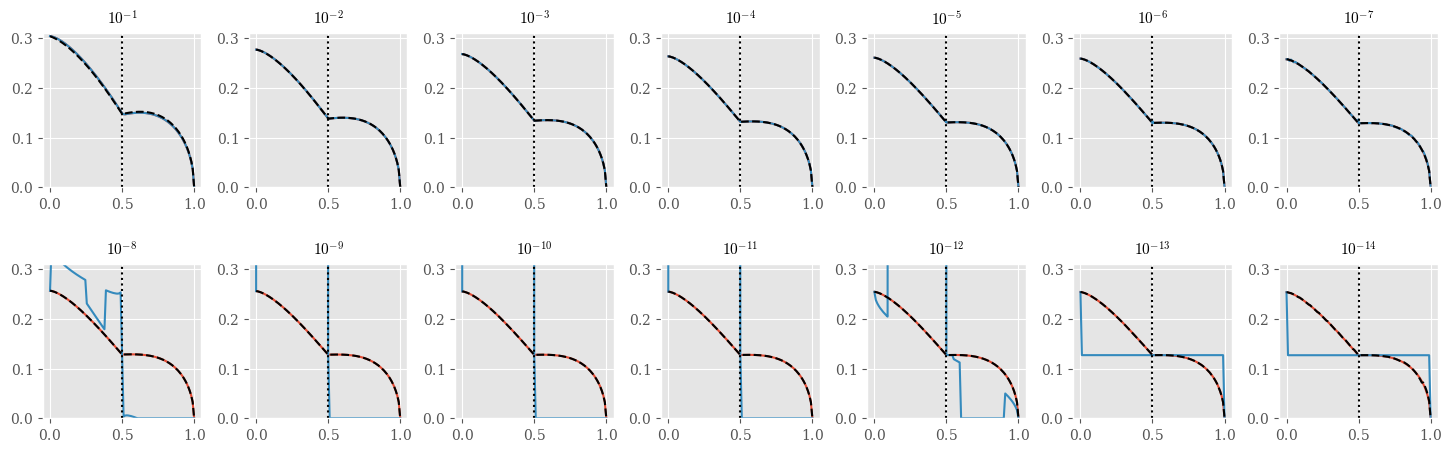

In [32]:
# Test
fig, ax = plt.subplots(nrows=2, ncols=len(ε_mp)//2, figsize = (18,5))
for i in range(len(ε_mp)):
    ε = ε_np[i]

    λₓ_1 = ((ε - n_1) + mp.sqrt(n_1 - ε*ε)) / (n_2 * ε)                            # Not branch, but relevant
    λₓ_2 = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, λₓ_1, N) + mp.linspace(λₓ_1, n_1/n_2, N)[1:] + mp.linspace(n_1/n_2, λₓ_2, N)[1:-1] + mp.linspace(λₓ_2, n_1, N)
    A_pre = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    A_mp = mp.linspace(n_0, n_1 - ε, N) + A_pre + mp.linspace(n_1 + ε, n_2, N)
    A_np = np.fromiter((np.float64(x) for x in A_mp), dtype=np.float64, count=len(A_mp))
    
    
    #H_float_no_asy  = np.r_[H_stable(Λ_np[Λ_np <= np.float64(λₓ)], ε, True, False), H_stable(Λ_np[Λ_np > np.float64(λₓ)], ε, False, False)]
    #H_float_yes_asy = np.r_[H_stable(Λ_np[Λ_np <= np.float64(λₓ)], ε, True, True), H_stable(Λ_np[Λ_np > np.float64(λₓ)], ε, False, True)]
    H_float_no_asy  = f_out[i].copy()[N:-N]
    H_float_yes_asy = f_out_a[i].copy()[N:-N]
    
    np.clip(H_float_no_asy, 0.0, 5.0, H_float_no_asy)
    
    f_a = [E_mp( a,ε)/(ε*ε * mp.log(ε*ε)) for a in A_mp]
    
    ax[i // 7,i % 7].plot(Λ, f_a[N:-N])
    ax[i // 7,i % 7].plot(Λ, H_float_no_asy)
    ax[i // 7,i % 7].plot(Λ, H_float_yes_asy, '--', c='black')
    ax[i // 7,i % 7].set_title(leg[i], {'fontsize':11})
    ax[i // 7,i % 7].axvline(x=λₓ, color='black', linestyle = ':')
    
    ax[i // 7,i % 7].set_ylim([0.0, 0.31])

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=0.5)

We see that beyond $10^{-7}$, numerical errors incurr in catastrophic cancelation. Notice that $\varepsilon^2 \log \varepsilon^2 \sim 10^{-15}$. Thus, for safe computations, we can use the assymptotic expansions as soon as $\varepsilon \leq 10^{-7}$. Moreoever, we see that the assymptotic expansion displays a very quick convergence. Through a more careful look, however, we see that it is needed to tight the tolerance up to $10^{-5}$.

In [33]:
# Define range of values for ε
nA = np.arange(1,16,1)
ε_mp, leg = [mp.mpf('10') ** -a for a in nA], [r'$10^{'+'{0}'.format(-a)+'}$' for a in nA]
ε_np = np.fromiter((np.float64(x) for x in ε_mp), dtype=np.float64, count=len(ε_mp))

In [34]:
N  = 50
f_out, f_mp = np.zeros( (2, len(ε_mp), (4+2)*N - 3) )
# Evaluate f
for i in range(len(ε_mp)):
    ε = ε_mp[i]
    λₓ_1 = ((ε - n_1) + mp.sqrt(n_1 - ε*ε)) / (n_2 * ε)                            # Not branch, but relevant
    λₓ_2 = ((ε - n_1) + mp.sqrt(n_1 + ε*ε)) / (n_2 * ε)                            # Branch point
    Λ = mp.linspace(n_0, λₓ_1, N) + mp.linspace(λₓ_1, n_1/n_2, N)[1:] + mp.linspace(n_1/n_2, λₓ_2, N)[1:-1] + mp.linspace(λₓ_2, n_1, N)
    A_pre = [n_1 - (n_1 - n_2*λ)*ε for λ in Λ]
    A_mp = mp.linspace(n_0, n_1 - ε, N) + A_pre + mp.linspace(n_1 + ε, n_2, N)
    A_np = np.fromiter((np.float64(x) for x in A_mp), dtype=np.float64, count=len(A_mp))
    
    # Compute exact for errors
    f_a = [E_mp(a,ε)/(ε*ε * mp.log(ε*ε)) for a in A_mp]
    f_mp[i] = np.fromiter((np.float64(x) for x in f_a), dtype=np.float64, count=len(f_a))

    # Compute long double 
    ε = ε_np[i]
    if ε >= 1e-5:
        f_a = E_np(A_np, ε) / (ε*ε * np.log(ε*ε))
    else:
        f_a = E_np(A_np, ε, True) / (ε*ε * np.log(ε*ε))
    f_out[i] = np.asarray(f_a).copy()

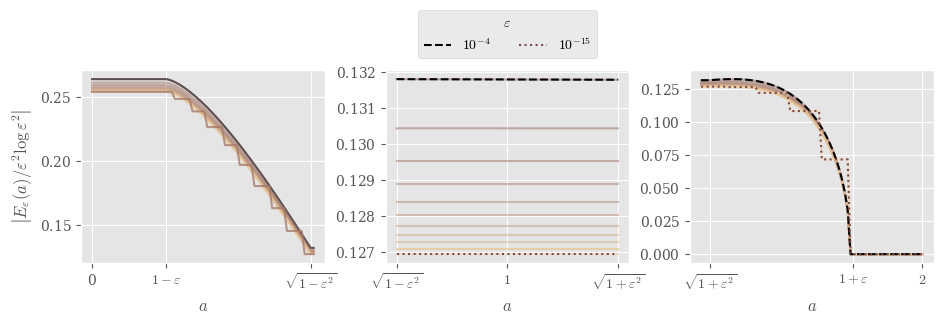

In [35]:
# Plot E(a) inside [0,2]
fig, ax = plt.subplots(nrows=1, ncols=3, figsize = (11,2.5))

for i in range(3,len(ε_mp)):
    ax[0].plot(f_out[i][N//2:2*N+1], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )    # [0, 1-ε, √(1-ε^2)]
    ax[1].plot(np.arange(len(A))[2*N-1:4*N-2], f_out[i][2*N-1:4*N-2], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )    # [√(1-ε^2), 1, √(1+ε^2)]
    ax[2].plot(np.arange(len(A))[4*N-6:-N//2], f_out[i][4*N-6:-N//2], color = colorFader('#723d46','#ffe1a8',i/len(ε_mp)), alpha = 0.5, zorder = 1 )    # [√(1+ε^2),1+ε,2]

    if i == 3:
        ax[0].plot(f_out[i][N//2:2*N+1], color = 'xkcd:black', alpha = 0.5, zorder = 1 )
        ax[1].plot(np.arange(len(A))[2*N-1:4*N-2], f_out[i][2*N-1:4*N-2], color = 'xkcd:black', linestyle = '--', label = leg[i], zorder = 3 )
        ax[2].plot(np.arange(len(A))[4*N-6:-N//2], f_out[i][4*N-6:-N//2], color = 'xkcd:black', linestyle = '--', label = leg[i], zorder = 3 )
    
    if i == len(ε_mp)-1:
        ax[0].plot(f_out[i][N//2:2*N+1], color = colorFader('#ffe1a8','#723d46',i/len(ε_mp)), alpha = 0.5, zorder = 1 )
        ax[1].plot(np.arange(len(A))[2*N-1:4*N-2], f_out[i][2*N-1:4*N-2], color = colorFader('#ffe1a8','#723d46',i/len(ε_mp)), linestyle = ':', label = leg[i], zorder = 3 )
        ax[2].plot(np.arange(len(A))[4*N-6:-N//2], f_out[i][4*N-6:-N//2], color = colorFader('#ffe1a8','#723d46',i/len(ε_mp)), linestyle = ':', label = leg[i], zorder = 3 )

# First panel
ax_loc = [0, N-N//2, 2*N-1 - N//2] #[0.0, np.float64(n_1 - ε), np.float64(mp.sqrt(n_1 - ε*ε))]
ax_lbl = [plt.Text(0, 0, '$\\mathdefault{0}$'), plt.Text(N-N//2, 0, '$1-\\varepsilon$' ), plt.Text(2*N-1-N//2, 0, '$\\sqrt{1-\\varepsilon^2}$' )]
ax[0].set_xticks(ax_loc, ax_lbl);

# Second panel
ax_loc = [2*N-1, 3*N-2, 4*N-3] #[0.0, np.float64(n_1 - ε), np.float64(mp.sqrt(n_1 - ε*ε))]
ax_lbl = [plt.Text(2*N-1, 0, '$\\sqrt{1-\\varepsilon^2}$'), plt.Text(3*N-1, 0, '$1$' ), plt.Text(4*N-3, 0, '$\\sqrt{1+\\varepsilon^2}$' )]
ax[1].set_xticks(ax_loc, ax_lbl);

# Second panel
ax_loc = [4*N-3, 5*N-3, 6*N-4 - N//2] #[0.0, np.float64(n_1 - ε), np.float64(mp.sqrt(n_1 - ε*ε))]
ax_lbl = [plt.Text(4*N-3, 0, '$\\sqrt{1+\\varepsilon^2}$'), plt.Text(5*N-3, 0, '$1+\\varepsilon$' ), plt.Text(6*N-3 - N//2, 0, '$2$' )]
ax[2].set_xticks(ax_loc, ax_lbl);

# General info
ax[0].set_ylabel(r'$\left| E_\varepsilon (a) / \varepsilon^2 \log \varepsilon^2 \right|$')
[ax[i].set_xlabel(r'$a$') for i in range(3)]
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), ncols = 4, reverse = False, title = r'$\varepsilon$')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.025)
# –––––––– Store –––––––– #
#plt.savefig('E_plots.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

We can also evaluate the error:

In [36]:
import pandas as pd

In [44]:
Abs_scaled   = [abs(f_out - f_mp)[i,N+1:-N].max() for i in range(len(ε_mp)-1)]
ε_Factors    = [-ε_np[i] * ε_np[i] * np.log(ε_np[i]*ε_np[i])  for i in range(len(ε_mp)-1)]
Abs_unscaled = [Abs_scaled[i] * ε_Factors[i]  for i in range(len(ε_mp)-1)]
pd.DataFrame({'$\\varepsilon^2 \log \\varepsilon^2$':ε_Factors, 'Scaled':Abs_scaled, 'Unscaled': Abs_unscaled}, index = leg[:-1])

,$\varepsilon^2 \log \varepsilon^2$,Scaled,Unscaled
$10^{-1}$,4.605170e-02,6.691869e-14,3.081720e-15
$10^{-2}$,9.210340e-04,7.822110e-11,7.204429e-14
$10^{-3}$,1.381551e-05,6.449434e-08,8.910222e-13
$10^{-4}$,1.842068e-07,5.794816e-06,1.067445e-12
$10^{-5}$,2.302585e-09,9.056541e-07,2.085346e-15
$10^{-6}$,2.763102e-11,1.969947e-08,5.443164e-19
$10^{-7}$,3.223619e-13,2.167754e-09,6.988013e-22
$10^{-8}$,3.684136e-15,4.021048e-09,1.481409e-23
$10^{-9}$,4.144653e-17,9.657044e-08,4.002510e-24
$10^{-10}$,4.605170e-19,1.624779e-07,7.482386e-26


Most of the error takes place at the intervals $[1-\varepsilon,\sqrt{1-\varepsilon^2}]$ and $[\sqrt{1+\varepsilon^2}, 1+\varepsilon]$. This can be seen by evaluating the stable approximation without the asymptotic approximation of $\varphi$ which becomes worse as $\varepsilon < 10^{-13}$.

In [38]:
Abs_scaled   = [abs(f_out - f_mp)[i,2*N:-2*N].max() for i in range(len(ε_mp)-1)]
Abs_unscaled = [-Abs_scaled[i] * ε_np[i] * ε_np[i] * np.log(ε_np[i]*ε_np[i])  for i in range(len(ε_mp)-1)]
pd.DataFrame({'Scaled':Abs_scaled, 'Unscaled': Abs_unscaled}, index = leg[:-1])

,Scaled,Unscaled
$10^{-1}$,6.691869e-14,3.081720e-15
$10^{-2}$,7.822110e-11,7.204429e-14
$10^{-3}$,6.449434e-08,8.910222e-13
$10^{-4}$,5.794816e-06,1.067445e-12
$10^{-5}$,9.056541e-07,2.085346e-15
$10^{-6}$,1.407725e-08,3.889688e-19
$10^{-7}$,1.398252e-09,4.507432e-22
$10^{-8}$,9.387750e-10,3.458575e-24
$10^{-9}$,4.730335e-09,1.960560e-25
$10^{-10}$,2.871563e-10,1.322404e-28


---